In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, FloatType, LongType, StringType
from pyspark.sql.functions import col, avg, count, desc, split, trim ,regexp_extract , lower, when, explode, round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker

## Setup

In [2]:
SMALL = "../data/small/"
LARGE = "../data/32m/"
DATA = LARGE

In [3]:
# Consistent style across all plots
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})

In [4]:
spark = SparkSession.builder \
    .appName("SparkleMovie") \
    .master("local[*]") \
    .config("spark.driver.memory", "10g") \
    .getOrCreate()

# Réduit le bruit dans les logs
spark.sparkContext.setLogLevel("ERROR")

print(f"Spark version : {spark.version}")
print("Session démarrée ✓")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/16 17:49:04 WARN Utils: Your hostname, MacBook-M4-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.10.42.119 instead (on interface en0)
26/03/16 17:49:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/16 17:49:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version : 4.1.1
Session démarrée ✓


In [5]:
# --- Load ratings ---
ratings_schema = StructType([
    StructField("userId",    IntegerType(), nullable=False),
    StructField("movieId",   IntegerType(), nullable=False),
    StructField("rating",    FloatType(),   nullable=False),
    StructField("timestamp", LongType(),    nullable=False),
])

# --- Load movies ---
movies_schema = StructType([
    StructField("movieId", IntegerType(), nullable=False),
    StructField("title",   StringType(),  nullable=False),
    StructField("genres",  StringType(),  nullable=False),
])

ratings = spark.read.csv(DATA + "ratings.csv", header=True, schema=ratings_schema)
movies  = spark.read.csv(DATA + "movies.csv",  header=True, schema=movies_schema)

In [6]:
print("=== RATINGS ===")
print(f"Rows: {ratings.count():,}")
ratings.printSchema()
ratings.show(5)

print("\n=== MOVIES ===")
print(f"Rows: {movies.count():,}")
movies.printSchema()
movies.show(5, truncate=False)  # truncate=False pour voir les titres complets

=== RATINGS ===


Rows: 32,000,204
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|     17|   4.0|944249077|
|     1|     25|   1.0|944250228|
|     1|     29|   2.0|943230976|
|     1|     30|   5.0|944249077|
|     1|     32|   5.0|943228858|
+------+-------+------+---------+
only showing top 5 rows

=== MOVIES ===
Rows: 87,585
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Co

PySpark ne peut pas nativement mettre nullable à false, il faut faire une étape supplémentaire pour s’assurer des valeurs non nulles.

In [7]:
def audit_dataframe(df, name):
    """Check nulls and basic stats for a DataFrame."""
    print(f"=== {name} — {df.count():,} rows, {len(df.columns)} cols ===")
    
    # Null counts per column
    null_counts = df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in df.columns
    ])
    print("Null counts:")
    null_counts.show()
    
    # Duplicate rows
    total    = df.count()
    distinct = df.distinct().count()
    print(f"Duplicates: {total - distinct:,}")

audit_dataframe(ratings, "ratings")
audit_dataframe(movies,  "movies")

=== ratings — 32,000,204 rows, 4 cols ===
Null counts:


+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+



Duplicates: 0
=== movies — 87,585 rows, 3 cols ===
Null counts:
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+

Duplicates: 0


In [8]:
# Ratings should be between 0.5 and 5.0 (half-star increments)
print("=== Rating distribution ===")
ratings.groupBy("rating").count().orderBy("rating").show(20)

# Movies with no genre listed
print("=== Movies with no genre ===")
movies.filter(col("genres") == "(no genres listed)").count()

=== Rating distribution ===


+------+-------+
|rating|  count|
+------+-------+
|   0.5| 525132|
|   1.0| 946675|
|   1.5| 531063|
|   2.0|2028622|
|   2.5|1685386|
|   3.0|6054990|
|   3.5|4290105|
|   4.0|8367654|
|   4.5|2974000|
|   5.0|4596577|
+------+-------+

=== Movies with no genre ===


7080

## Nettoyage des données

### Bilan de l'audit qualité

Le dataset est globalement propre :
- Aucune valeur nulle dans aucune colonne
- Aucun doublon détecté
- Toutes les notes sont dans la plage valide (0.5 à 5.0)

### Cas particulier : films sans genre

Certains films ont la valeur `(no genres listed)` dans la colonne `genres` :
- **Small** : 34 films sur 9 742 (0,35%)
- **Large** : 7 080 films sur 87 585 (8%)

**Décision prise** : on ne supprime pas ces films du dataset principal.
Les algorithmes ALS et KNN se basent uniquement sur les notes des utilisateurs —
le genre n'intervient pas. Supprimer ces films appauvrirait inutilement les recommandations.

En revanche, le système de recommandation basé sur le contenu (Phase 2b) nécessite
les genres pour calculer des similarités. On crée donc un sous-ensemble `movies_with_genres`
réservé à cette phase uniquement.

### Datasets disponibles pour la suite

| Variable | Contenu | Utilisé pour |
|---|---|---|
| `ratings_clean` | Toutes les notes valides | ALS, KNN, exploration |
| `movies_clean` | Tous les films | ALS, KNN, exploration |
| `movies_with_genres` | Films avec genre uniquement | Content-based (TF-IDF) |

In [9]:
# Drop rows with any null (safety net — audit showed 0 nulls, but good practice)
ratings_clean = ratings.dropna()
movies_clean  = movies.dropna()

# Verify rating range: must be between 0.5 and 5.0 inclusive
ratings_clean = ratings_clean.filter(
    (col("rating") >= 0.5) & (col("rating") <= 5.0)
)

# Subset for content-based recommendation (genres required)
movies_with_genres = movies_clean.filter(
    col("genres") != "(no genres listed)"
)

# Sanity check
print(f"ratings_clean      : {ratings_clean.count():>7,} rows")
print(f"movies_clean       : {movies_clean.count():>7,} rows")
print(f"movies_with_genres : {movies_with_genres.count():>7,} rows")
print(f"Dropped (no genre) : {movies_clean.count() - movies_with_genres.count():>7,} rows")

ratings_clean      : 32,000,204 rows
movies_clean       :  87,585 rows
movies_with_genres :  80,505 rows
Dropped (no genre) :   7,080 rows


## Analyse exploratoire

### Films les mieux notés

Un tri naïf par moyenne favorise les films peu connus avec une seule note parfaite.
On applique un seuil minimum de 50 ratings pour ne garder que les films
suffisamment évalués pour que leur moyenne soit représentative.

In [10]:
ratings_with_title = ratings_clean.join(movies_clean, on="movieId", how="inner")

# Compute average rating and number of ratings per movie
top_movies = (
    ratings_with_title
    .groupBy("movieId", "title")
    .agg(
        spark_round(avg("rating"), 2).alias("avg_rating"),
        count("rating").alias("num_ratings")
    )
    .filter(col("num_ratings") >= 50)   # minimum threshold
    .orderBy(desc("avg_rating"), desc("num_ratings"))
)

top_movies.show(10, truncate=False)

+-------+--------------------------------+----------+-----------+
|movieId|title                           |avg_rating|num_ratings|
+-------+--------------------------------+----------+-----------+
|171011 |Planet Earth II (2016)          |4.45      |1956       |
|159817 |Planet Earth (2006)             |4.44      |2948       |
|170705 |Band of Brothers (2001)         |4.43      |2811       |
|318    |Shawshank Redemption, The (1994)|4.4       |102929     |
|171495 |Cosmos                          |4.33      |615        |
|858    |Godfather, The (1972)           |4.32      |66440      |
|202439 |Parasite (2019)                 |4.31      |11670      |
|179135 |Blue Planet II (2017)           |4.3       |1163       |
|198185 |Twin Peaks (1989)               |4.3       |1140       |
|220528 |Twelve Angry Men (1954)         |4.29      |449        |
+-------+--------------------------------+----------+-----------+
only showing top 10 rows


### Genres les plus populaires

La colonne `genres` contient des valeurs combinées séparées par `|`
(ex: `"Action|Comedy|Drama"`). On utilise `split` + `explode` pour
transformer chaque genre en ligne distincte, ce qui permet de compter
les occurrences par genre.

+--------------------+----------+
|               genre|num_movies|
+--------------------+----------+
|               Drama|     34175|
|              Comedy|     23123|
|            Thriller|     11823|
|             Romance|     10369|
|              Action|      9668|
|         Documentary|      9363|
|              Horror|      8654|
|               Crime|      6976|
|           Adventure|      5402|
|              Sci-Fi|      4907|
|           Animation|      4617|
|            Children|      4520|
|             Mystery|      4013|
|             Fantasy|      3851|
|                 War|      2325|
|             Western|      1696|
|             Musical|      1059|
|           Film-Noir|       353|
|                IMAX|       195|
| We're Comin' To ...|         1|
+--------------------+----------+



<Axes: title={'center': 'Number of Movies per Genre'}, xlabel='genre'>

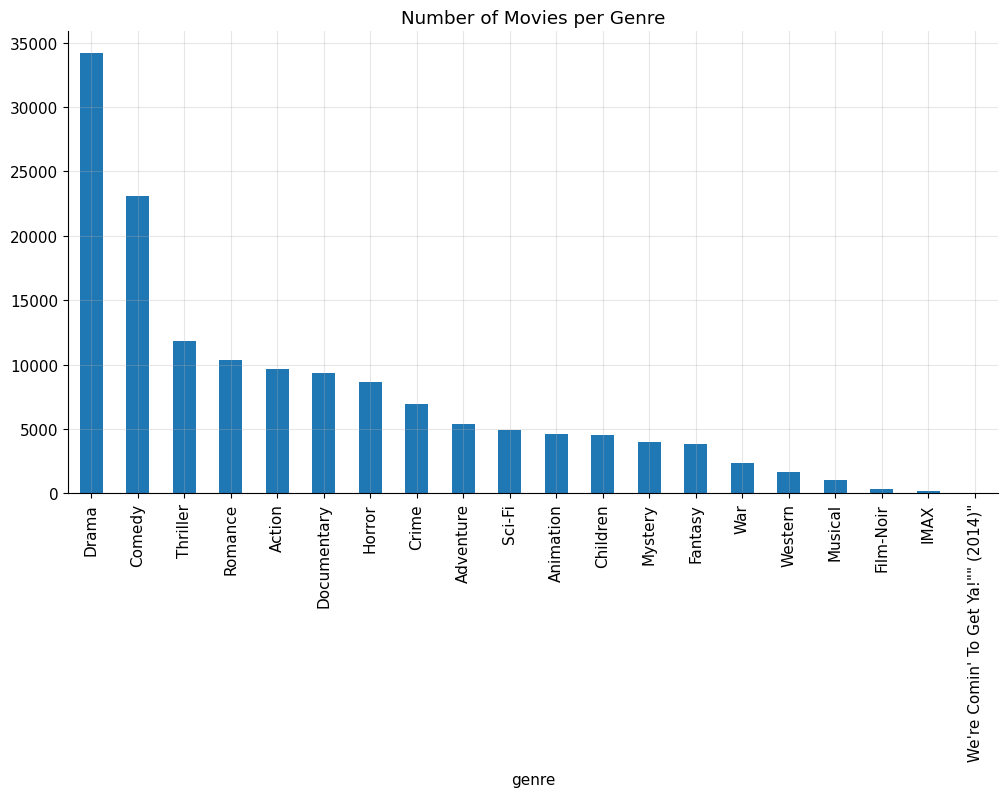

In [11]:
# Explode the pipe-separated genres into individual rows
genres_exploded = (
    movies_with_genres
    .select(explode(split(col("genres"), "\\|")).alias("genre"))
)

# Count and rank genres by number of movies
genre_counts = (
    genres_exploded
    .groupBy("genre")
    .agg(count("*").alias("num_movies"))
    .orderBy(desc("num_movies"))
)

genre_counts.show(20)
genre_counts.toPandas().plot.bar(x="genre", y="num_movies", legend=False, figsize=(12,6), title="Number of Movies per Genre")

### Nettoyage des genres

L'analyse du large dataset révèle une entrée corrompue dans la colonne `genres` :
un titre de film s'est glissé dans cette colonne suite à un problème d'échappement
de virgule dans le CSV source. On filtre les valeurs non reconnues en se basant
sur la liste officielle des genres MovieLens.

In [12]:
genre_counts.toPandas().tail(1)[["genre", "num_movies"]]


,genre,num_movies
19,"We're Comin' To Get Ya!"""" (2014)""",1


In [13]:
# Official MovieLens genre list (from dataset README)
VALID_GENRES = {
    "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
    "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "IMAX",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
}

# Re-explode with whitelist filter
genre_counts_clean = (
    movies_with_genres
    .select(explode(split(col("genres"), "\\|")).alias("genre"))
    .filter(col("genre").isin(VALID_GENRES))
    .groupBy("genre")
    .agg(count("*").alias("num_movies"))
    .orderBy(desc("num_movies"))
)

genre_counts_clean.show(20)

+-----------+----------+
|      genre|num_movies|
+-----------+----------+
|      Drama|     34175|
|     Comedy|     23123|
|   Thriller|     11823|
|    Romance|     10369|
|     Action|      9668|
|Documentary|      9363|
|     Horror|      8654|
|      Crime|      6976|
|  Adventure|      5402|
|     Sci-Fi|      4907|
|  Animation|      4617|
|   Children|      4520|
|    Mystery|      4013|
|    Fantasy|      3851|
|        War|      2325|
|    Western|      1696|
|    Musical|      1059|
|  Film-Noir|       353|
|       IMAX|       195|
+-----------+----------+



## Visualisations exploratoires

On convertit les résultats agrégés Spark en pandas pour la visualisation.
Cette conversion est acceptable ici car on travaille sur des résultats
agrégés (quelques dizaines à centaines de lignes), pas sur le dataset brut.

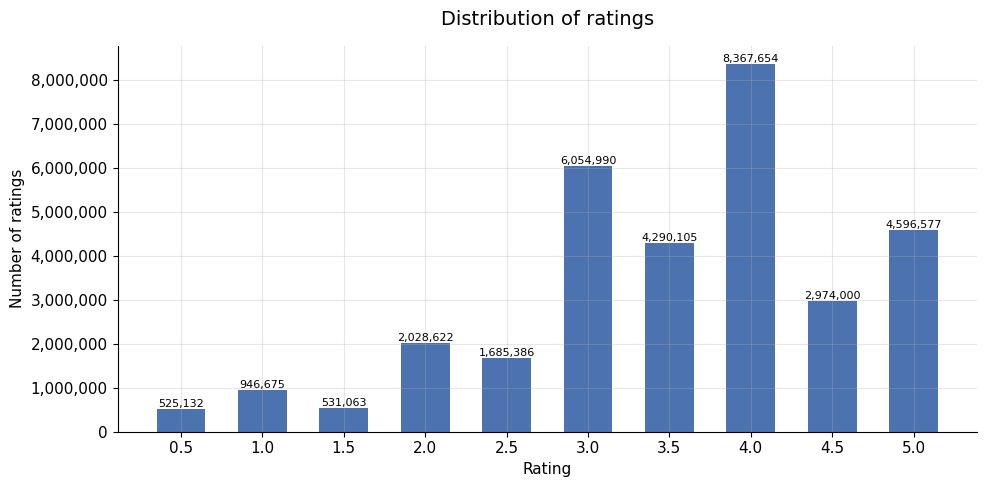

In [14]:
# Convert to pandas
ratings_dist = (
    ratings_clean
    .groupBy("rating")
    .agg(count("rating").alias("count"))
    .orderBy("rating")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    ratings_dist["rating"].astype(str),
    ratings_dist["count"],
    color="#4C72B0",
    width=0.6
)

ax.set_title("Distribution of ratings", fontsize=14, pad=15)
ax.set_xlabel("Rating")
ax.set_ylabel("Number of ratings")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Annotate each bar with its value
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=8
    )

plt.tight_layout()
plt.savefig("../outputs/01_rating_distribution.png", dpi=150)
plt.show()

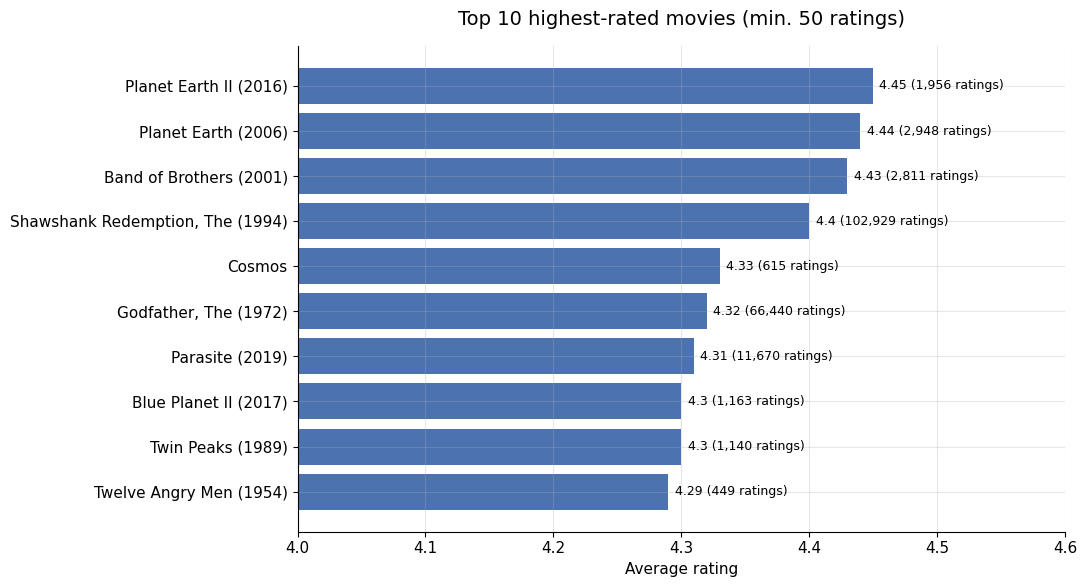

In [15]:
# Convert top_movies to pandas — take top 10
top_movies_pd = top_movies.limit(10).toPandas()

# Shorten long titles for readability
top_movies_pd["short_title"] = top_movies_pd["title"].str.slice(0, 35)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    top_movies_pd["short_title"][::-1],   # reverse for descending order top-to-bottom
    top_movies_pd["avg_rating"][::-1],
    color="#4C72B0"
)

ax.set_title("Top 10 highest-rated movies (min. 50 ratings)", fontsize=14, pad=15)
ax.set_xlabel("Average rating")
ax.set_xlim(4.0, 4.6)

# Annotate with avg_rating and num_ratings
for i, (bar, row) in enumerate(zip(bars, top_movies_pd.iloc[::-1].itertuples())):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{row.avg_rating} ({row.num_ratings:,} ratings)",
        va="center", fontsize=9
    )

plt.tight_layout()
plt.savefig("../outputs/02_top_movies.png", dpi=150)
plt.show()

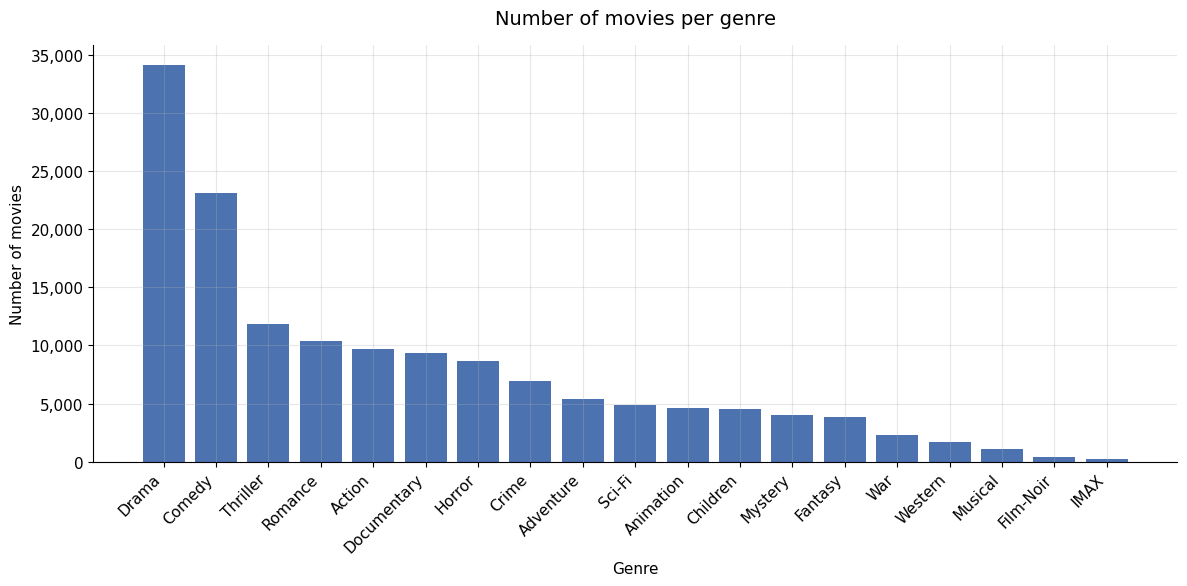

In [16]:
genre_pd = genre_counts_clean.toPandas()

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(genre_pd["genre"], genre_pd["num_movies"], color="#4C72B0")
ax.set_title("Number of movies per genre", fontsize=14, pad=15)
ax.set_xlabel("Genre")
ax.set_ylabel("Number of movies")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../outputs/03_genre_distribution.png", dpi=150)
plt.show()

## Interprétation des résultats exploratoires

### Distribution des notes (dataset large — 32M ratings)

La distribution est asymétrique vers les notes élevées, avec un pic marqué à **4.0**
(8,3 millions de ratings). Les notes basses (0.5 à 1.5) sont très peu représentées.

Ce biais s'explique par le profil des utilisateurs MovieLens : ce sont des cinéphiles
actifs qui choisissent délibérément les films qu'ils regardent et notent. Ils ne notent
pas au hasard — ils notent ce qu'ils ont aimé ou voulu voir. La distribution reflète
donc un **biais de sélection**, pas le goût moyen de la population générale.

> À noter : les notes à incréments entiers (1.0, 2.0, 3.0, 4.0, 5.0) sont
> systématiquement plus fréquentes que leurs équivalents demi-étoile. Les utilisateurs
> ont tendance à arrondir leur évaluation.

### Top 10 des films les mieux notés (seuil : 50 ratings minimum)

Les résultats sur le large dataset révèlent une observation inattendue : les trois
premières places sont occupées par des **séries documentaires TV** (Planet Earth II,
Planet Earth, Band of Brothers), et non par des films au sens strict.

Cela reflète une caractéristique du dataset : MovieLens indexe aussi bien les séries
que les films. Ces contenus attirent un public très ciblé et passionné, ce qui gonfle
artificiellement leur note moyenne par rapport aux blockbusters grand public.

Parmi les films traditionnels, on retrouve les classiques attendus :
**The Shawshank Redemption (1994)** avec 102 929 ratings et une moyenne de 4.4 —
le volume de votes en fait la référence la plus fiable du classement.

### Distribution des genres (dataset large)

**Drama** (34 175 films) et **Comedy** (23 123) dominent largement le catalogue,
représentant à eux deux près de 40% des entrées. Le fait qu'un film appartienne
souvent à plusieurs genres simultanément explique que la somme des genres dépasse
le nombre total de films.

Les genres de niche comme **Film-Noir** (353) et **IMAX** (195) sont très peu
représentés — ce qui aura un impact sur la qualité des recommandations content-based
pour ces catégories (moins de films similaires disponibles).

## Feature engineering & préparation des tags

### Extraction de l'année de sortie

On extrait l'année depuis le titre (format "Film (YYYY)") pour disposer
d'une variable temporelle exploitable dans les analyses futures.

### Nettoyage des tags

Les tags utilisateurs sont normalisés (lowercase, doublons supprimés)
puis agrégés par film pour être utilisés dans le TF-IDF content-based.

In [17]:
# --- Extract year from title ---
# Spark 4.x : regexp_extract returns "" when no match — use when() instead of nullif()
movies_clean = movies_clean.withColumn(
    "year",
    when(
        regexp_extract(col("title"), r"\((\d{4})\)$", 1) != "",
        regexp_extract(col("title"), r"\((\d{4})\)$", 1).cast("integer")
    ).otherwise(None)
)

# Sanity check
missing_year = movies_clean.filter(col("year").isNull()).count()
print(f"Movies without year : {missing_year}")
movies_clean.select("movieId", "title", "year").show(5, truncate=False)

# --- Load and clean tags ---
tags_schema = StructType([
    StructField("userId",    IntegerType(), nullable=False),
    StructField("movieId",   IntegerType(), nullable=False),
    StructField("tag",       StringType(),  nullable=False),
    StructField("timestamp", LongType(),    nullable=False),
])

tags_raw = spark.read.csv(f"{DATA}tags.csv", header=True, schema=tags_schema)

tags_clean = (
    tags_raw
    .dropna(subset=["tag"])
    .withColumn("tag", trim(lower(col("tag"))))
    .filter(col("tag") != "")
    .filter(col("tag").rlike("[a-zA-Z]"))
    .dropDuplicates(["movieId", "tag"])
)

print(f"tags_raw   : {tags_raw.count():,} rows")
print(f"tags_clean : {tags_clean.count():,} rows")
tags_clean.show(5, truncate=False)

Movies without year : 797
+-------+----------------------------------+----+
|movieId|title                             |year|
+-------+----------------------------------+----+
|1      |Toy Story (1995)                  |1995|
|2      |Jumanji (1995)                    |1995|
|3      |Grumpier Old Men (1995)           |1995|
|4      |Waiting to Exhale (1995)          |1995|
|5      |Father of the Bride Part II (1995)|1995|
+-------+----------------------------------+----+
only showing top 5 rows
tags_raw   : 2,000,072 rows


tags_clean : 1,067,465 rows


+------+-------+-----------+----------+
|userId|movieId|tag        |timestamp |
+------+-------+-----------+----------+
|58    |61132  |parody     |1672551601|
|58    |136020 |espionage  |1672551092|
|81    |5952   |magic      |1556671093|
|109   |66659  |tyler perry|1257977442|
|303   |59315  |military   |1551555330|
+------+-------+-----------+----------+
only showing top 5 rows


## Persistance des données nettoyées

Les DataFrames nettoyés sont sauvegardés au format Parquet.
Ce format natif Spark préserve le schema et offre de meilleures
performances en lecture que le CSV.

In [18]:
PATH = DATA.replace("../data/", "../data/processed/")

ratings_clean.write.parquet(f"{PATH}ratings_clean.parquet",       mode="overwrite")
movies_clean.write.parquet(f"{PATH}movies_clean.parquet",         mode="overwrite")
movies_with_genres.write.parquet(f"{PATH}movies_with_genres.parquet", mode="overwrite")
tags_clean.write.parquet(f"{PATH}tags_clean.parquet",             mode="overwrite")

print(f"Data saved to {PATH} ✓")

Data saved to ../data/processed/32m/ ✓


26/03/16 20:50:51 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:707)
	at org.apache.spark.storage.BlockManagerMasterE

## Conclusion de l'exploration

Le dataset MovieLens (large) est de bonne qualité globale : aucune valeur nulle,
aucun doublon, notes dans la plage attendue. Le principal point de vigilance est
la présence de séries TV mélangées aux films, et de 7 080 films sans genre (8%
du catalogue) qui seront exclus de l'approche content-based uniquement.

Les données sont prêtes pour la modélisation. Trois approches seront comparées
dans `02_modelisation.ipynb` :
- **ALS** (Alternating Least Squares) — filtrage collaboratif matriciel
- **Content-based** — similarité entre films via TF-IDF sur les genres
- **KNN** — similarité entre utilisateurs via leurs historiques de notes

> `tags.csv` n'est pas exploré ici mais sera utilisé en Phase 2b pour enrichir
> les profils de films au-delà des genres : les tags libres des utilisateurs
> apportent une description sémantique plus fine, améliorant la qualité
> des recommandations content-based.